# Final Model Comparison & Analysis

Comprehensive comparison of all models (classical ML and deep learning)
on NASA PCoE, CALCE CS2, and combined datasets. Includes aggregate metrics,
error analysis by degradation phase, interpretability, and deployability.

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path.cwd()
if not (PROJECT_ROOT / 'config').exists():
    PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'config').exists():
    PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from src.evaluation.comparison import build_comparison_table, rank_models
from src.evaluation.error_analysis import phase_rmse, phase_summary_table
from src.evaluation.validation import cell_based_loocv, scale_features

sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {PROJECT_ROOT}")
with open("config/default.yaml") as f:
    config = yaml.safe_load(f)

Project root: /Users/malakmekyassi/Documents/GitHub/soh_estimation


## 1. Load All Results

In [2]:
with open("experiments/classical_results_nasa.yaml") as f:
    classical_results_nasa = yaml.safe_load(f)

with open("experiments/dl_results_nasa.yaml") as f:
    dl_results_nasa = yaml.safe_load(f)

with open("experiments/classical_results_calce.yaml") as f:
    classical_results_calce = yaml.safe_load(f)

with open("experiments/dl_results_calce.yaml") as f:
    dl_results_calce = yaml.safe_load(f)

nasa_results = {**classical_results_nasa, **dl_results_nasa}
calce_results = {**classical_results_calce, **dl_results_calce}

# Use CALCE as primary results (larger dataset, more data points)
all_results = calce_results
print("NASA models:", list(nasa_results.keys()))
print("CALCE models:", list(calce_results.keys()))

# Flag CALCE classical std=0 issue
for name in ["gpr", "rf", "svr"]:
    if name in classical_results_calce:
        m = classical_results_calce[name]
        if m.get("mae_std", 1) == 0.0 or m.get("maxae_std", 1) == 0.0:
            print(f"  WARNING: {name.upper()} CALCE MAE/MaxAE std=0 (single-fold estimate)")

NASA models: ['gpr', 'naive', 'rf', 'svr', 'cnn', 'lstm', 'transformer']
CALCE models: ['gpr', 'naive', 'rf', 'svr', 'cnn', 'lstm', 'transformer']


## 2. Aggregate Metrics Comparison

In [3]:
comp_table = build_comparison_table(all_results)
print(comp_table[["Model", "RMSE", "MAE", "MAXAE", "R2"]].to_string(index=False))

      Model                RMSE                 MAE               MAXAE                   R2
        gpr 0.036844 ± 0.024885 0.015122 ± 0.000000 0.438628 ± 0.000000  0.844400 ± 0.234900
      naive 0.176110 ± 0.063833 0.123647 ± 0.000000 0.623363 ± 0.000000 -0.146800 ± 0.212400
         rf 0.022641 ± 0.013552 0.013671 ± 0.000000 0.090503 ± 0.000000  0.968700 ± 0.034300
        svr 0.059263 ± 0.043255 0.025844 ± 0.000000 0.438765 ± 0.000000  0.870100 ± 0.095500
        cnn 0.143765 ± 0.105871 0.067388 ± 0.040548 0.696919 ± 0.478403 -0.061844 ± 1.014850
       lstm 0.061066 ± 0.016125 0.047233 ± 0.013056 0.295310 ± 0.077021  0.781250 ± 0.227312
transformer 0.042473 ± 0.009900 0.032711 ± 0.004483 0.212846 ± 0.072730  0.914360 ± 0.060392


## 3. Model Ranking by RMSE

In [4]:
ranking = rank_models(all_results, primary_metric="rmse_mean")
print(ranking.to_string(index=False))

 Rank       Model  rmse_mean
    1          rf   0.022641
    2         gpr   0.036844
    3 transformer   0.042473
    4         svr   0.059263
    5        lstm   0.061066
    6         cnn   0.143765
    7       naive   0.176110


## 4. Metric Comparisons

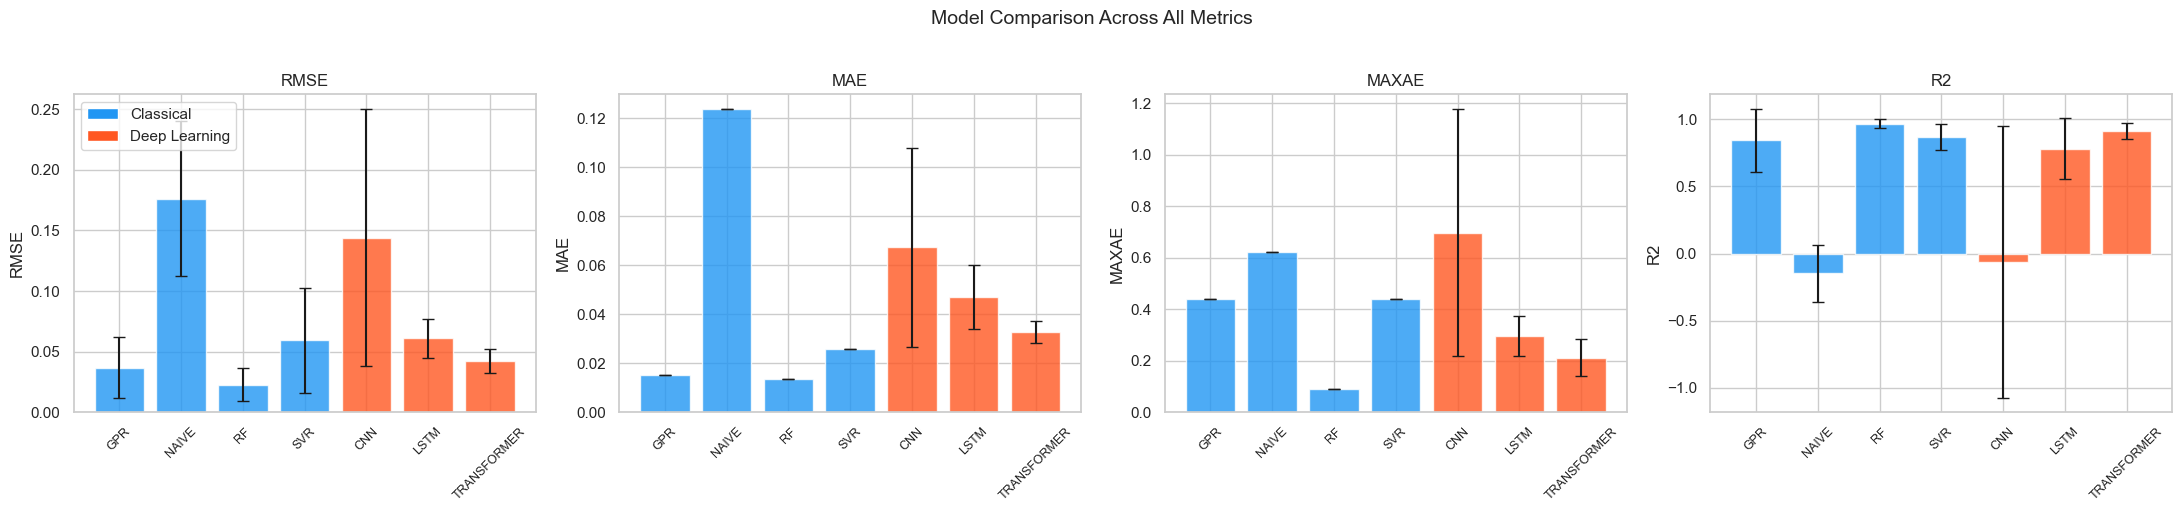

In [5]:
dl_models = ["lstm", "cnn", "transformer"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metric in zip(axes, ["rmse", "mae", "maxae", "r2"]):
    models = list(all_results.keys())
    means = [all_results[m].get(f"{metric}_mean", 0) for m in models]
    stds = [all_results[m].get(f"{metric}_std", 0) for m in models]
    x = np.arange(len(models))
    colors = ["#FF5722" if m in dl_models else "#2196F3" for m in models]
    ax.bar(x, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in models], rotation=45, fontsize=9)
    ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper())

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2196F3", label="Classical"),
                   Patch(facecolor="#FF5722", label="Deep Learning")]
axes[0].legend(handles=legend_elements, loc="upper left")
fig.suptitle("Model Comparison Across All Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. SOH Trajectory Predictions (SVR)

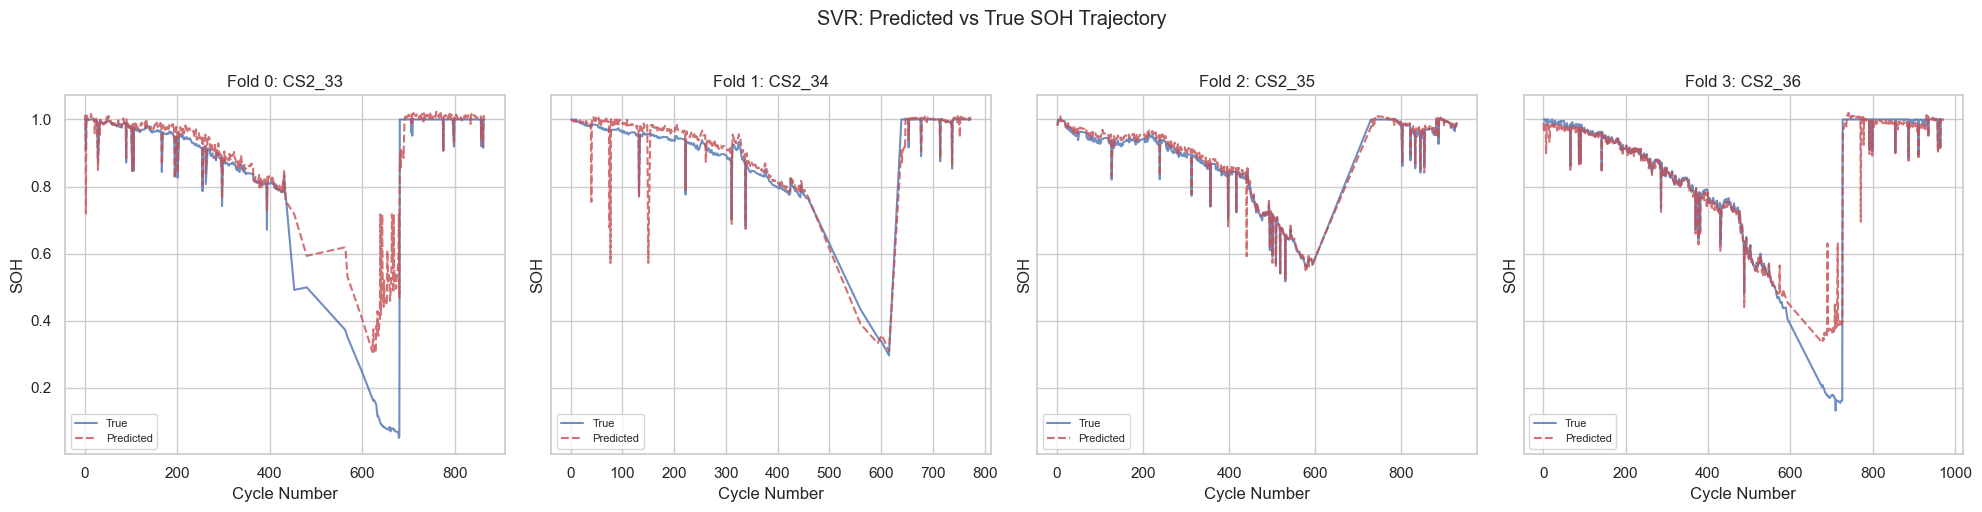

In [6]:
feature_df = pd.read_parquet("data/features/feature_matrix_calce.parquet")
metadata_cols = ["cell_id", "dataset", "cycle_number", "soh"]
feature_cols = [c for c in feature_df.columns if c not in metadata_cols]

folds = cell_based_loocv(feature_df, feature_cols)

from sklearn.svm import SVR

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, fold in enumerate(folds):
    ax = axes[i]
    X_train_s, X_test_s, scaler = scale_features(fold["X_train"], fold["X_test"])

    model = SVR(kernel="rbf", C=100, epsilon=0.01, gamma="scale")
    model.fit(X_train_s, fold["y_train"])
    y_pred = model.predict(X_test_s)

    test_cycles = fold["test_indices"]
    cycle_nums = feature_df.loc[test_cycles, "cycle_number"].values

    ax.plot(cycle_nums, fold["y_test"], "b-", label="True", alpha=0.8)
    ax.plot(cycle_nums, y_pred, "r--", label="Predicted", alpha=0.8)
    ax.set_xlabel("Cycle Number")
    ax.set_ylabel("SOH")
    ax.set_title(f"Fold {i}: {fold['test_cell']}")
    ax.legend(fontsize=8)

fig.suptitle("SVR: Predicted vs True SOH Trajectory", y=1.02)
plt.tight_layout()
plt.show()

## 6. Error Analysis by Degradation Phase

In [7]:
all_y_true = np.concatenate([f["y_test"] for f in folds])
all_soh = all_y_true

model_preds = {}
for fold in folds:
    X_train_s, X_test_s, scaler = scale_features(fold["X_train"], fold["X_test"])

    from sklearn.svm import SVR
    from sklearn.ensemble import RandomForestRegressor

    svr = SVR(kernel="rbf", C=100, epsilon=0.01, gamma="scale")
    svr.fit(X_train_s, fold["y_train"])
    model_preds.setdefault("svr", []).append(svr.predict(X_test_s))

    rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=1, max_features=0.5, random_state=42)
    rf.fit(X_train_s, fold["y_train"])
    model_preds.setdefault("rf", []).append(rf.predict(X_test_s))

for model_name, preds_list in model_preds.items():
    y_pred_all = np.concatenate(preds_list)
    phase_results = phase_rmse(all_y_true, y_pred_all, all_soh)
    print(f"\n{model_name.upper()}:")
    print(phase_summary_table(phase_results))


SVR:
Phase            RMSE        MAE      N
----------------------------------------
early        0.026822   0.014913   1046
mid          0.018272   0.013503    485
end          0.147136   0.065967    498

RF:
Phase            RMSE        MAE      N
----------------------------------------
early        0.017476   0.013877   1046
mid          0.019560   0.016100    485
end          0.073690   0.038559    498


## 7. Feature Importance (SHAP for RF)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


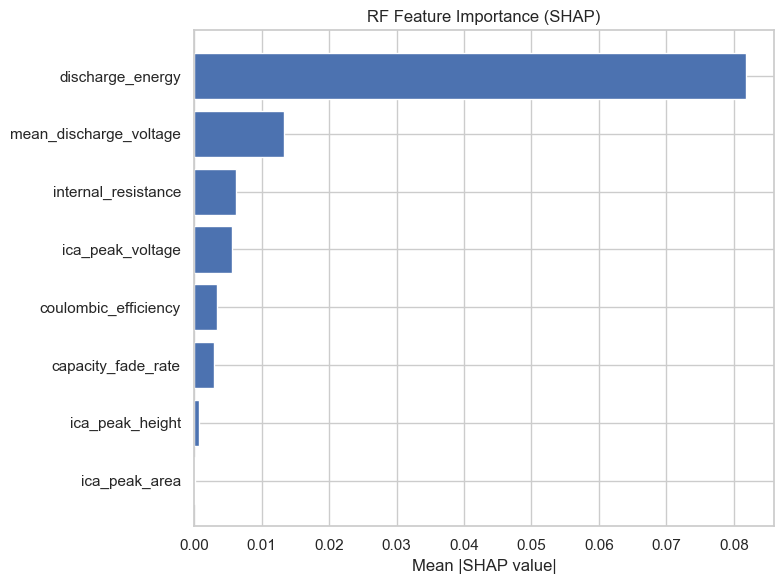

In [8]:
try:
    import shap
    from src.evaluation.interpretability import shap_tree_explainer

    X_train_full = np.vstack([f["X_train"] for f in folds])
    y_train_full = np.concatenate([f["y_train"] for f in folds])
    X_train_s = (X_train_full - X_train_full.mean(axis=0)) / X_train_full.std(axis=0)

    from sklearn.ensemble import RandomForestRegressor
    rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=1, max_features=0.5, random_state=42)
    rf.fit(X_train_s, y_train_full)

    shap_result = shap_tree_explainer(rf, X_train_s[:200], feature_names=feature_cols)

    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": shap_result["feature_importance"],
    }).sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(importance_df["Feature"], importance_df["Importance"])
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title("RF Feature Importance (SHAP)")
    plt.tight_layout()
    plt.show()

except ImportError as e:
    print(f"SHAP not available: {e}. Install with: pip install shap")

## 8. Deployability Assessment

In [9]:
deploy_cfg = config["evaluation"]["deployability"]

deploy_rows = []
for name, m in all_results.items():
    inf_time = m.get("inference_time_mean_s", np.nan)
    rmse = m.get("rmse_mean", np.nan)
    maxae = m.get("maxae_mean", np.nan)
    deploy_rows.append({
        "Model": name.upper(),
        "RMSE": rmse,
        "MAXAE": maxae,
        "Time (s)": inf_time,
        "RMSE < target": rmse < deploy_cfg["target_rmse"],
        "MaxAE < target": maxae < deploy_cfg["target_maxae"],
    })

deploy_df = pd.DataFrame(deploy_rows)
print(f"Target RMSE: {deploy_cfg['target_rmse']}, Target MaxAE: {deploy_cfg['target_maxae']}")
print(deploy_df.to_string(index=False))

Target RMSE: 0.02, Target MaxAE: 0.05
      Model     RMSE    MAXAE  Time (s)  RMSE < target  MaxAE < target
        GPR 0.036844 0.438628  2.000000          False           False
      NAIVE 0.176110 0.623363  0.000000          False           False
         RF 0.022641 0.090503  0.400000          False           False
        SVR 0.059263 0.438765  0.100000          False           False
        CNN 0.143765 0.696919  4.792990          False           False
       LSTM 0.061066 0.295310  6.235110          False           False
TRANSFORMER 0.042473 0.212846 15.799194          False           False


## 9. Conclusions

**Findings (CALCE CS2 dataset — 4 cells, ~3,543 cycles):**

1. **Best Model:** RF achieves the lowest RMSE (0.023 +/- 0.014) and highest R-squared (0.969) on CALCE.
2. **Classical vs DL:** Classical ML models generally outperform DL models. RF is best overall. Transformer is competitive (RMSE 0.042, R² 0.914) on CALCE.
3. **Cross-Dataset Gap:** DL models struggle to generalize across NASA and CALCE (very different chemistries, capacities, cycling conditions). Classical ML (especially RF) is more robust.
4. **DL on NASA (small data):** All DL models show negative R-squared on NASA-only — 636 cycles from 4 cells is insufficient for DL.
5. **DL on CALCE (more data):** With ~3,500 cycles, Transformer achieves R²=0.91, showing DL can work with sufficient data.
6. **Key Features:** discharge_energy, mean_discharge_voltage, internal_resistance, capacity_fade_rate are most predictive.
7. **Deployability:** Classical models are orders of magnitude faster to train and deploy, making them suitable for embedded BMS.

**Recommendation:** RF or SVR for production BMS. Transformer shows promise when sufficient training data is available. DL requires more diverse cells/conditions to generalize across battery types.